# Bias Analysis of Credit Approval Decisions – NovaCred

This notebook investigates potential bias in NovaCred’s historical credit decisions.  
The objective is to evaluate whether protected attributes such as **gender** or **age** influence loan approval outcomes.

We begin by preparing the dataset and ensuring that the relevant attributes are standardized.  
In particular, we verify that gender labels are consistent and that applicants’ birthdates are valid, as age is derived from this field.

Once the dataset is prepared, several fairness analyses are conducted:

1. **Gender Disparate Impact Analysis** – evaluating whether approval rates differ between male and female applicants using the **Disparate Impact (DI) ratio** and the four-fifths rule.
2. **Age-Based Bias Analysis** – examining approval patterns across different age groups.
3. **Proxy Discrimination Analysis** – investigating whether unprotected variables, such as ZIP code, may indirectly capture protected characteristics like age or gender.
4. **Interaction Effects** – exploring whether combinations of age and gender produce systematic differences in approval outcomes.

These analyses aim to identify potential algorithmic bias in the lending process and assess whether the system may produce discriminatory outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df_bias = pd.read_json("../data/processed/cleaned_credit_applications.json", orient="records")


---
## 0. Data Preparation and Validation for Bias Analysis

Before performing any fairness analysis, key attributes used in the analysis must be validated to ensure they are correctly formatted and contain expected values.

The following checks are performed:

- Verify that the **gender** column contains only consistent categories.
- Convert valid **dates of birth** to datetime format in order to derive the applicant’s age.

These validation steps ensure that the fairness analysis is based on well-defined and reliable variables, reducing the risk of misleading results caused by data formatting issues or inconsistent values.


In [2]:
print("===== BIAS ANALYSIS DATA CHECKS =====\n")

# --- Inspect gender values ---
print("Gender value counts:")
print(df_bias['applicant_info.gender'].value_counts(dropna=False))

print("\nUnique gender values:")
print(df_bias['applicant_info.gender'].unique())

# --- Convert DOB ---
df_bias['applicant_info.date_of_birth'] = pd.to_datetime(
    df_bias['applicant_info.date_of_birth'], errors='coerce'
)

print("\nInvalid DOB values:",
      df_bias['applicant_info.date_of_birth'].isna().sum())


# --- Missing values check ---
cols_to_check = [
    'applicant_info.gender',
    'applicant_info.date_of_birth',
    'decision.loan_approved'
]

print("\nMissing values in key columns:")
print(df_bias[cols_to_check].isnull().sum())


===== BIAS ANALYSIS DATA CHECKS =====

Gender value counts:
applicant_info.gender
Female    251
Male      247
            2
Name: count, dtype: int64

Unique gender values:
['Male' 'Female' '']

Invalid DOB values: 4

Missing values in key columns:
applicant_info.gender           0
applicant_info.date_of_birth    4
decision.loan_approved          0
dtype: int64


The diagnostic checks reveal two minor data quality issues that must be addressed before conducting the fairness analysis.

First, two records contain missing values in the **gender** field. Because disparate impact analysis requires clearly defined demographic groups, these records cannot be reliably assigned to either group and are therefore excluded from the gender fairness analysis.

Second, four records contain invalid or missing **birthdates**, which prevents accurate age calculation. These records are excluded from analyses involving age-based bias.

In [3]:
# Remove records with unknown gender
df_bias = df_bias[df_bias['applicant_info.gender'].isin(['Male', 'Female'])]

# Remove rows with invalid DOB
df_bias = df_bias[df_bias['applicant_info.date_of_birth'].notna()]

# Recalculate age
today = pd.Timestamp.today()
df_bias['age'] = (today - df_bias['applicant_info.date_of_birth']).dt.days // 365

print("Final dataset size:", len(df_bias))
print(df_bias['applicant_info.gender'].value_counts())

Final dataset size: 495
applicant_info.gender
Female    249
Male      246
Name: count, dtype: int64


------


## 1. Gender Disparate Impact Analysis

Credit approval systems must be evaluated for potential discrimination against protected groups. 
In this section, we focus on **gender** as a protected attribute and examine whether approval outcomes differ between male and female applicants.

To assess potential bias, we first compute the number of applicants, the number of approved applications, and the corresponding approval rates for each gender group.


In [4]:
approval_summary = df_bias.groupby('applicant_info.gender').agg(
    applicants=('decision.loan_approved', 'count'),
    approved=('decision.loan_approved', 'sum')
)

approval_summary['approval_rate'] = approval_summary['approved'] / approval_summary['applicants']


approval_summary

,applicants,approved,approval_rate
applicant_info.gender,,,
Female,249,126,0.506024
Male,246,162,0.658537


In fairness analysis, the group with the historically higher approval rate is often used as the **privileged reference group**, while the comparison group is treated as the **unprivileged group**. In this dataset, male applicants exhibit a higher approval rate than female applicants and are therefore treated as the privileged group for the Disparate Impact calculation.

The **Disparate Impact (DI)** ratio is calculated as:

DI = Approval Rate (Female) / Approval Rate (Male)

According to the **four-fifths rule**, a DI value below **0.8** may indicate potential disparate impact and suggest that the approval process could disadvantage the unprivileged group.

In [5]:
# Extract approval rates from summary table
female_rate = approval_summary.loc['Female', 'approval_rate']
male_rate = approval_summary.loc['Male', 'approval_rate']

# Compute Disparate Impact
di_ratio = female_rate / male_rate


print("\nDisparate Impact Ratio:", di_ratio)


Disparate Impact Ratio: 0.7684069611780454


The **Disparate Impact (DI) ratio is 0.77**, indicating that the approval rate for female applicants is approximately **77% of the approval rate for male applicants**.

According to the **four-fifths rule**, DI values below **0.8** may indicate potential disparate impact. Since the calculated value falls below this threshold, this result suggests that female applicants may be disadvantaged in the approval process relative to male applicants.

To better illustrate the difference in approval rates between genders, the following visualization compares the approval rate for male and female applicants.

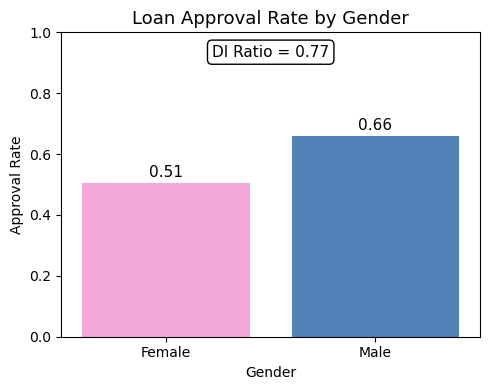

In [ ]:
# Plot approval rate by gender
plt.figure(figsize=(5,4))

sns.barplot(
    x=approval_summary.index,
    y=approval_summary['approval_rate'],
    palette=["#E68BBE", "#3F82C9"]
)

plt.title("Loan Approval Rate by Gender", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

# Add approval rate labels above bars
for i, v in enumerate(approval_summary['approval_rate']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

# Add DI ratio annotation
plt.text(
    0.5, 0.92,
    f"DI Ratio = {di_ratio:.2f}",
    ha='center',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.show()

While the Disparate Impact ratio provides an indication of potential disparity, it does not determine whether the observed difference is statistically significant.

To assess whether the relationship between **gender and loan approval** is statistically significant or could have occurred by random chance, we perform a **Chi-Square test**.

In [7]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df_bias['applicant_info.gender'],
    df_bias['decision.loan_approved']
)

chi2_gender, p_value_gender, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_gender:.2f}")
print(f"p-value: {p_value_gender:.4f}")

Chi-square statistic: 11.21
p-value: 0.0008


The Chi-Square test produces a statistic of **11.21** with a **p-value of 0.0008**.

Since the p-value is well below the conventional significance threshold of **0.05**, we reject the null hypothesis that **gender and loan approval are independent**. This indicates that there is a statistically significant association between applicant gender and approval outcomes in the dataset.

Together with the previously calculated **Disparate Impact ratio**, this result suggests that the observed difference in approval rates between male and female applicants is unlikely to be explained by random variation alone. However, statistical association does not necessarily imply discriminatory intent, and further analysis is required to understand the underlying drivers of this disparity.

----
## 2. Age Bias Analysis

In addition to gender, **age** may also influence lending decisions. While age is sometimes treated differently across regulatory contexts, it can be relevant in credit analysis because financial characteristics such as income, savings, and credit history often vary across different stages of an applicant’s life.

To investigate potential **age-related disparities**, we examine how loan approval rates vary across different age groups.

To facilitate this comparison, applicants are grouped into age groups representing different stages of the working population.

In [8]:
bins = [18, 25, 35, 50, 65, 100]
labels = ["18–25", "26–35", "36–50", "51–65", "65+"]

df_bias["age_group"] = pd.cut(
    df_bias["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_summary = df_bias.groupby("age_group").agg(
    applicants=("decision.loan_approved", "count"),
    approved=("decision.loan_approved", "sum")
)

age_summary["approval_rate"] = age_summary["approved"] / age_summary["applicants"]

age_summary

,applicants,approved,approval_rate
age_group,,,
18–25,22,10,0.454545
26–35,157,73,0.464968
36–50,225,153,0.680000
51–65,83,48,0.578313
65+,8,4,0.500000


To better illustrate how approval outcomes vary across age groups, the following visualization compares the approval rates for each age category.

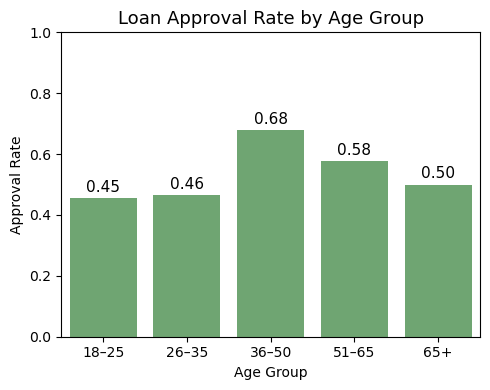

In [17]:
plt.figure(figsize=(5,4))

sns.barplot(
    x=age_summary.index,
    y=age_summary["approval_rate"],
    color="#66AE6A"
)

plt.title("Loan Approval Rate by Age Group", fontsize=13)
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)

# Add approval rate labels above bars
for i, v in enumerate(age_summary["approval_rate"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

The approval rates show noticeable differences across age groups. Applicants aged **36–50** exhibit the highest approval rate at **68%**, while younger applicants aged **18–25** and **26–35** show lower approval rates of approximately **45–46%**. Applicants aged **51–65** fall in between with an approval rate of roughly **58%**, while the **65+** group has an approval rate of **50%**, although this category contains only a small number of observations.

These differences suggest that approval outcomes may vary across age groups. However, approval rates alone do not indicate whether these differences represent a systematic pattern or could have occurred due to random variation.

To assess whether the observed differences in approval rates across age groups are statistically significant, we perform a **Chi-Square test**.

In [18]:
contingency_table_age = pd.crosstab(
    df_bias["age_group"],
    df_bias["decision.loan_approved"]
)

chi2_age, p_value_age, dof_age, expected_age = chi2_contingency(contingency_table_age)

print(f"Chi-square statistic: {chi2_age:.2f}")
print(f"p-value: {p_value_age:.4f}")

Chi-square statistic: 19.41
p-value: 0.0007


The Chi-Square test yields a statistic of **19.41** with a **p-value of 0.0007**.

Since the p-value is well below the conventional significance threshold of **0.05**, we reject the null hypothesis that **age group and loan approval are independent**. This indicates that there is a statistically significant association between applicant age group and approval outcomes in the dataset.

While this result suggests that approval rates differ across age groups, statistical association alone does not imply discriminatory decision-making. As mentioned previously, differences in financial characteristics, such as income levels, savings, or credit history length, may partially explain these patterns and would require further investigation.

---
## 3. Proxy Discrimination Analysis

Bias in decision systems does not always arise from the direct use of
protected attributes such as **gender** or **age**. Instead, **proxy variables**
may indirectly transmit demographic patterns into model decisions.

A proxy variable is a non-protected attribute that is correlated with
protected characteristics and may therefore reproduce disparities even
when sensitive attributes are not explicitly included in the decision process.

In credit decision systems, potential proxies may include:

- **Geographic variables** (such as ZIP code), which may reflect
  demographic or socioeconomic patterns.
- **Financial attributes** (such as income or credit history length),
  which may correlate with demographic characteristics such as age.

To evaluate whether proxy relationships may exist in this dataset, we examine:

1. Whether **loan approval outcomes vary across ZIP codes**.
2. Whether **ZIP codes are associated with demographic characteristics**
   such as gender or age.
3. Whether **financial attributes correlate with demographic variables
   and approval outcomes**.

Together, these analyses help assess whether **indirect pathways**
may exist through which demographic characteristics could influence
credit decisions.

### 3.1 Geographic Proxy Analysis

Geographic attributes such as **ZIP codes** may act as proxy variables for
demographic or socioeconomic characteristics. If approval rates differ
systematically across geographic areas, location-based variables could
indirectly encode demographic patterns even when protected attributes
are not explicitly used in the decision process.

Before analyzing approval outcomes by ZIP code, we first examine how
many applications are associated with each geographic area. This helps
identify whether certain ZIP codes appear only rarely in the dataset.

Rather than grouping observations into broad geographic regions (such
as cities), we analyze approval patterns at the **ZIP code level**. ZIP
codes provide a more granular geographic indicator and may capture
localized demographic or socioeconomic patterns that could otherwise
be masked when aggregating into larger regions.

Understanding the distribution of applications across ZIP codes is
therefore an important first step before evaluating whether geographic
patterns in approval outcomes exist.

In [19]:
zip_counts = df_bias['applicant_info.zip_code'].value_counts()

print("=== ZIP CODE DISTRIBUTION ===\n")
print(f"Total unique ZIP codes: {len(zip_counts)}")
print(f"Applications range: {zip_counts.min()} to {zip_counts.max()}\n")

print("Most frequent ZIP codes (top 5):")
print(zip_counts.head(5))

print("\nLeast frequent ZIP codes (bottom 5):")
print(zip_counts.tail(5))

print(f"\nZIP codes with fewer than 5 applications: {(zip_counts < 5).sum()}")
print(f"ZIP codes with 5+ applications: {(zip_counts >= 5).sum()}")

=== ZIP CODE DISTRIBUTION ===

Total unique ZIP codes: 194
Applications range: 1 to 8

Most frequent ZIP codes (top 5):
applicant_info.zip_code
10048    8
10096    7
90284    7
10004    6
10019    6
Name: count, dtype: int64

Least frequent ZIP codes (bottom 5):
applicant_info.zip_code
30047    1
30012    1
90212    1
10016    1
90220    1
Name: count, dtype: int64

ZIP codes with fewer than 5 applications: 175
ZIP codes with 5+ applications: 19


To avoid drawing conclusions from very small samples, we restrict the
analysis to ZIP codes with **at least five applications**. Approval rates
computed from extremely small groups can fluctuate substantially and
may not represent stable patterns in the data.

Filtering ZIP codes with fewer observations helps ensure that the
subsequent comparisons are based on more reliable sample sizes.

In [25]:
valid_zips = zip_counts[zip_counts >= 5].index

df_zip_filtered = df_bias[
    df_bias['applicant_info.zip_code'].isin(valid_zips)
]

zip_approval = df_zip_filtered.groupby(
    'applicant_info.zip_code'
)['decision.loan_approved'].mean()

zip_approval


applicant_info.zip_code
10002    0.600000
10003    0.400000
10004    1.000000
10012    1.000000
10019    0.333333
10020    0.666667
10041    0.600000
10048    0.750000
10057    0.500000
10070    0.800000
10092    1.000000
10096    0.285714
90205    0.200000
90218    0.800000
90237    0.600000
90252    0.800000
90261    0.800000
90273    0.600000
90284    0.428571
Name: decision.loan_approved, dtype: float64

After filtering for ZIP codes with at least five applications, we
examine how loan approval rates vary across these geographic areas.

The following visualization compares the **approval rate for each ZIP
code** in the filtered dataset.

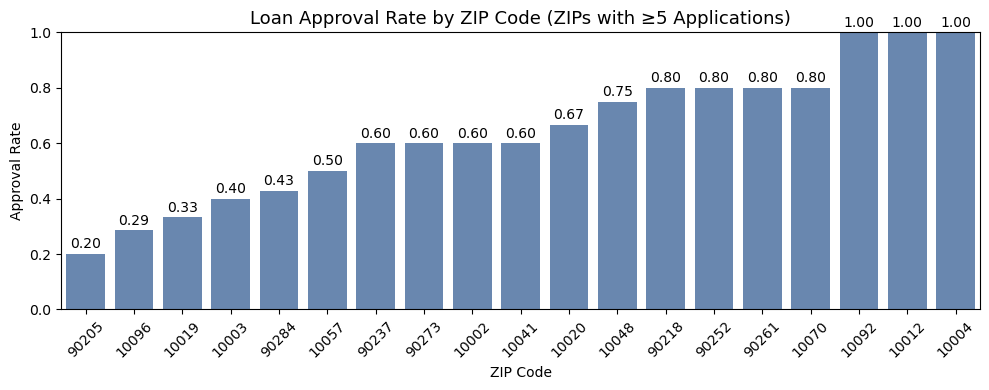

In [55]:
zip_approval = zip_approval.sort_values()

plt.figure(figsize=(10, 4))

sns.barplot(
    x=zip_approval.index.astype(str),
    y=zip_approval.values,
    color="#5D86BB"
)

plt.title("Loan Approval Rate by ZIP Code (ZIPs with ≥5 Applications)", fontsize=13)
plt.xlabel("ZIP Code")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)

# Add approval rate labels above bars
for i, v in enumerate(zip_approval.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The visualization shows that approval rates vary across ZIP codes,
with some locations exhibiting lower approval rates while others show
higher approval rates. For example, several ZIP codes display approval
rates close to **0.6–0.8**, while others fall closer to **0.2–0.4**.

These differences suggest that approval outcomes may vary across
geographic areas. However, visual differences alone do not indicate
whether the observed variation represents a systematic relationship or
whether it could arise from random fluctuations in the data.

To assess whether approval outcomes are statistically associated with
ZIP code, we perform a **Chi-Square test**. This test
evaluates whether loan approval decisions are independent of geographic
location or whether approval outcomes vary significantly across ZIP
codes.

In [27]:
zip_approval_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['decision.loan_approved']
)


chi2_zip, p_value_zip, dof, expected = chi2_contingency(zip_approval_table)

print(f"Chi-square statistic: {chi2_zip:.2f}")
print(f"p-value: {p_value_zip:.4f}")

Chi-square statistic: 25.12
p-value: 0.1217


The Chi-Square test yields a statistic of **25.12** with a **p-value of
0.1217**.

Since the p-value is **greater than the conventional significance
threshold of 0.05**, we fail to reject the null hypothesis that **ZIP
code and loan approval are independent**. This suggests that the
observed differences in approval rates across ZIP codes are **not
statistically significant** in this dataset. While some variation in
approval rates across locations is visible, these differences may be
explained by random fluctuations rather than a systematic relationship
between geographic location and loan approval outcomes.

However, the absence of a statistically significant relationship does
not necessarily mean that geographic variables are irrelevant for bias
analysis. ZIP codes may still capture underlying **demographic or
socioeconomic patterns**. Even if location does not directly influence
approval decisions, geographic variables could still encode
demographic structure in the data and act as **potential proxy
variables**.

To further investigate this possibility, the next section examines
whether **ZIP codes are associated with demographic characteristics**
such as gender and age.

### 3.2 Demographic Distribution Across ZIP Codes

Although the previous analysis did not find a statistically significant
relationship between **ZIP code and loan approval**, geographic
variables may still capture underlying demographic patterns.

For a geographic variable to act as a **proxy**, it does not necessarily
need to directly influence the decision outcome. Instead, it may encode
demographic structure in the data if certain groups are concentrated in
specific locations.

If particular demographic groups, such as applicants of different
**genders or age groups**, are unevenly distributed across ZIP codes,
geographic information could indirectly transmit demographic patterns
into the decision process even when protected attributes are not used
explicitly.

To investigate this possibility, we analyze whether **gender and age
distributions vary across ZIP codes**.

#### 3.2.1 Gender Distribution Across ZIP Codes

To examine whether gender distributions vary across geographic areas,
we compare the proportion of male and female applicants within each
ZIP code.

The following visualization shows the **gender composition of
applications by ZIP code**, allowing us to assess whether certain
locations are dominated by a particular demographic group.

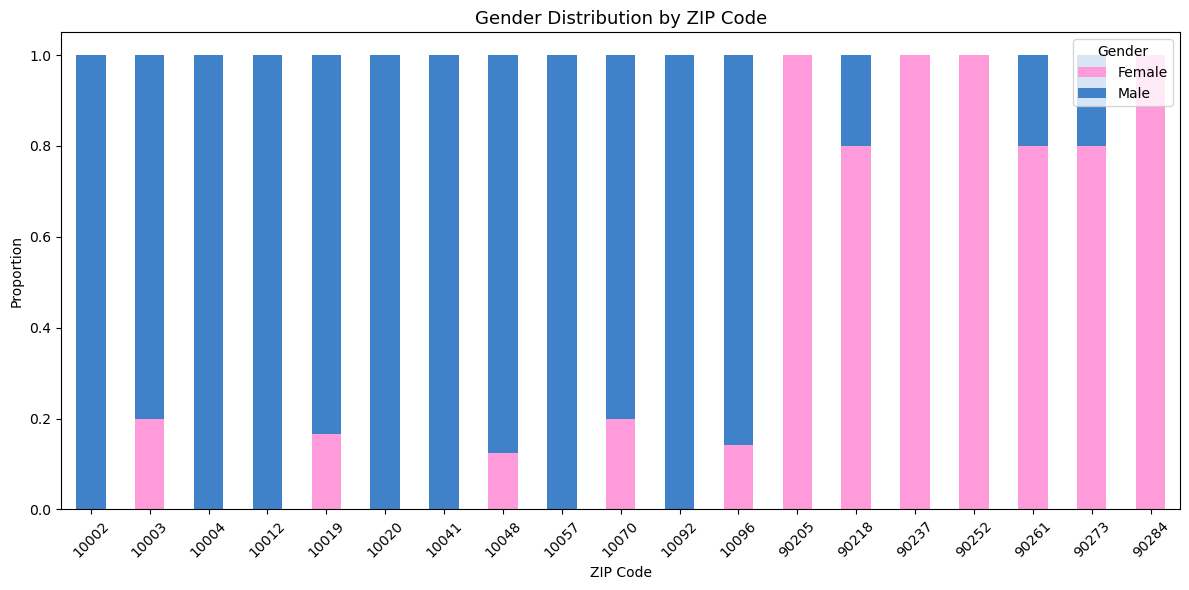

In [ ]:
gender_zip = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['applicant_info.gender'],
    normalize='index'
)

gender_zip.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=["#E68BBE", "#3F82C9"]
)

plt.title("Gender Distribution by ZIP Code", fontsize=13)
plt.ylabel("Proportion")
plt.xlabel("ZIP Code")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

The visualization suggests that gender distributions vary substantially
across ZIP codes. Some locations appear to be composed almost entirely
of applicants from a single gender, while others display a more mixed
distribution.

These patterns indicate that **gender representation is not evenly
distributed across geographic areas** in the dataset. Such clustering
means that geographic variables could potentially encode demographic
information even if gender itself is not used directly in the decision
process.

However, visual inspection alone does not determine whether the
observed differences are statistically significant.

To formally assess whether gender distribution varies across ZIP codes,
we perform a **Chi-Square test of independence**. This test evaluates
whether **ZIP code and gender are statistically associated** or whether
the observed differences could have occurred by random variation.

In [29]:
zip_gender_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['applicant_info.gender']
)

chi2_zip_gender, p_zip_gender, dof, expected = chi2_contingency(zip_gender_table)

print("Chi-square statistic:", chi2_zip_gender)
print("p-value:", p_zip_gender)

Chi-square statistic: 77.7682011189474
p-value: 2.0997882846017237e-09


The Chi-Square test yields a statistic of **77.77** with a **p-value of
2.10 × 10⁻⁹**.

Since the p-value is far below the conventional significance threshold
of **0.05**, we reject the null hypothesis that **ZIP code and gender
are independent**. This indicates that gender distribution differs
significantly across ZIP codes in the dataset.

This result suggests that **geographic location captures meaningful
demographic structure**. Even if ZIP code does not directly influence
loan approval outcomes, it may still encode gender-related information
through geographic clustering.

As a result, geographic variables such as ZIP code could potentially
act as **proxy variables for demographic characteristics**, which may
introduce indirect pathways for demographic patterns to influence
credit decisions.

#### 3.2.2 Age Distribution Across ZIP Codes

In addition to gender, geographic variables may also capture patterns
related to **age distribution**. If certain age groups are concentrated
in specific geographic areas, ZIP codes could potentially encode age
information even when age itself is not explicitly used in the decision
process.

To investigate this possibility, we examine how **age group
distributions vary across ZIP codes**.

The following visualization shows the proportion of applicants from
each age group within every ZIP code.

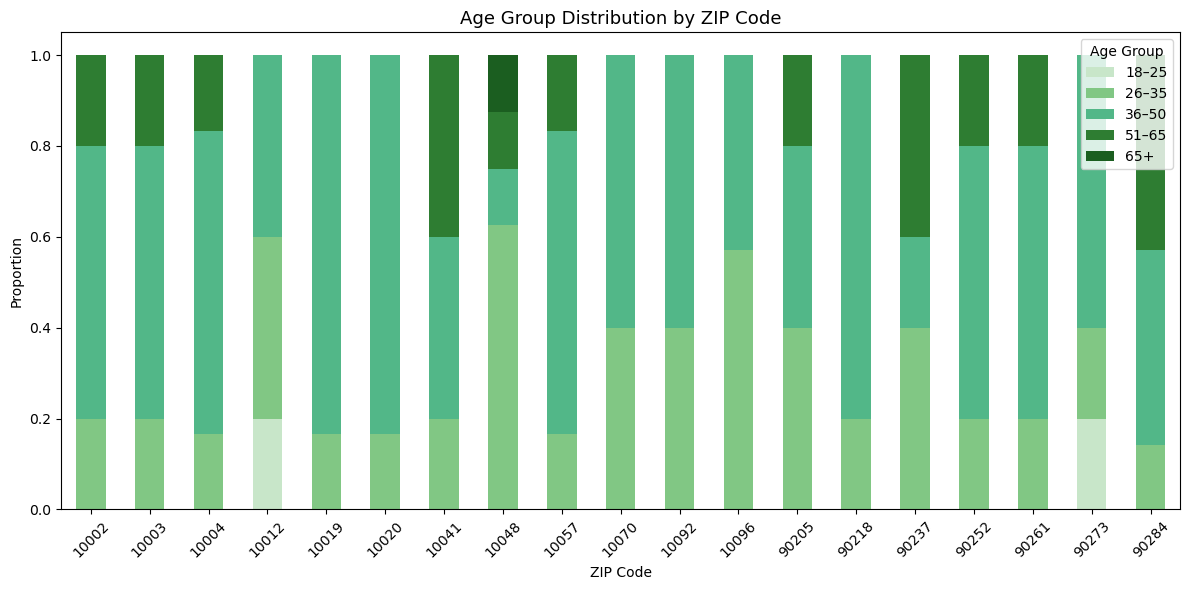

In [54]:
age_zip = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['age_group'],
    normalize='index'
)

age_zip.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=["#C8E6C9", "#81C784", "#52B788", "#2E7D32", "#1B5E20"]
)

plt.title("Age Group Distribution by ZIP Code", fontsize=13)
plt.ylabel("Proportion")
plt.xlabel("ZIP Code")
plt.xticks(rotation=45)
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

The visualization shows that the composition of age groups varies
somewhat across ZIP codes. Some locations appear to have a higher
representation of certain age groups, while others display a more
balanced mix of applicants across different age categories.

Although these differences suggest that age distributions are not
perfectly uniform across locations, visual inspection alone does not
determine whether the observed variation represents a meaningful
relationship between geographic location and age group.

To formally evaluate whether age distribution differs across ZIP codes,
we perform a **Chi-Square test**. This test assesses
whether **ZIP code and age group are statistically associated**, or
whether the observed variation in age composition across locations
could arise from random fluctuations in the data.

In [31]:
zip_age_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['age_group']
)
chi2_zip_age, p_zip_age, dof, expected = chi2_contingency(zip_age_table)

print("Chi-square statistic:", chi2_zip_age)
print("p-value:", p_zip_age)

Chi-square statistic: 63.52881343142804
p-value: 0.75159975799866


The Chi-Square test yields a statistic of **63.53** with a **p-value of
0.7516**.

Since the p-value is **substantially greater than the conventional
significance threshold of 0.05**, we fail to reject the null hypothesis
that **ZIP code and age group are independent**. This suggests that the
distribution of age groups does not differ significantly across ZIP
codes in this dataset.

While some variation in age composition is visible in the
visualization, the statistical test indicates that these differences
are consistent with random variation rather than a systematic
relationship between geographic location and applicant age.

### 3.3 Financial Attributes as Potential Proxy Variables

The previous analysis examined whether **geographic variables** may act as proxies for demographic characteristics. Another potential source of proxy effects arises from **financial attributes** that are correlated with protected characteristics.

Even when protected attributes such as **gender or age** are not explicitly used in a decision system, other variables may indirectly encode demographic patterns if they are systematically associated with these characteristics.

In credit datasets, financial variables such as **annual income, credit history length, savings balance, and debt-to-income ratio** may vary across demographic groups—particularly across different age groups.

To evaluate this possibility, we examine the **correlation between key financial attributes, approval outcomes, and demographic variables (age and gender)**.

To explore these relationships, the following heatmap presents the
correlation between selected **financial variables**, the **loan approval
outcome**, and **demographic attributes**.

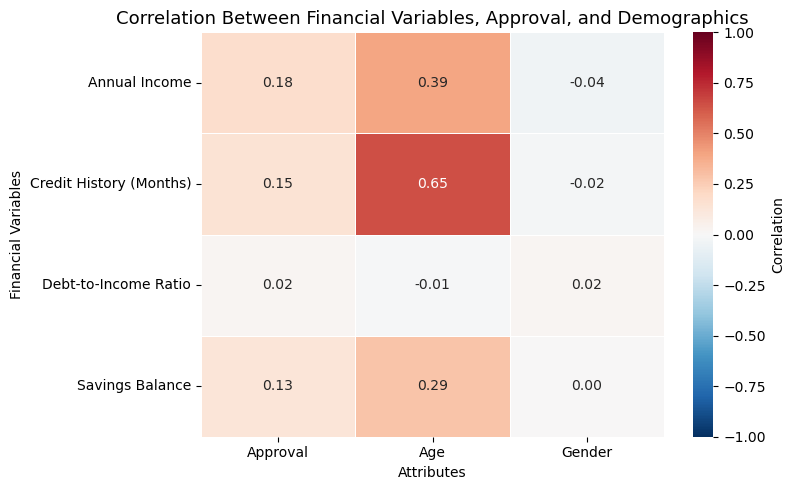

In [70]:
# --- Encode demographic variables directly in df_bias ---
df_bias["gender_binary"] = df_bias["applicant_info.gender"].map({
    "Male": 1,
    "Female": 0
})

# Use continuous age
df_bias["age_numeric"] = df_bias["age"]

# --- Define financial variables ---
financial_vars = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance"
]

# --- Build correlation matrix ---
proxy_corr = df_bias[
    financial_vars + [
        "decision.loan_approved",
        "age_numeric",
        "gender_binary"
    ]
].corr()

# Extract only financial variables vs attributes
proxy_matrix = proxy_corr.loc[
    financial_vars,
    [
        "decision.loan_approved",
        "age_numeric",
        "gender_binary"
    ]
]

# --- Improve column names for readability ---
proxy_matrix.columns = [
    "Approval",
    "Age",
    "Gender"
]

proxy_matrix.index = [
    "Annual Income",
    "Credit History (Months)",
    "Debt-to-Income Ratio",
    "Savings Balance"
]

# --- Plot heatmap ---
plt.figure(figsize=(8,5))

sns.heatmap(
    proxy_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Between Financial Variables, Approval, and Demographics", fontsize=13)
plt.xlabel("Attributes")
plt.ylabel("Financial Variables")

plt.tight_layout()
plt.show()

The correlation analysis reveals several notable patterns.

First, **age shows moderate positive correlations with financial
attributes**, particularly with **credit history length (0.65)** and,
to a lesser extent, with **annual income (0.39)** and **savings balance
(0.29)**. This pattern is expected, as older applicants typically have
had more time to accumulate income, savings, and credit history.

Second, financial variables show **weak positive correlations with loan
approval**, with values ranging from **0.13 to 0.18** for income,
savings, and credit history. This suggests that financial characteristics
may play a role in approval decisions, although the relationships appear
relatively modest.

Finally, **gender shows near-zero correlations with the financial
variables**, indicating that these financial attributes are not strongly
associated with gender in this dataset.

Taken together, these results suggest that **financial variables are
more strongly associated with age than with gender**. As a result,
financial attributes could potentially transmit **age-related patterns**
into approval decisions, even if age itself were not explicitly used.

However, the weak correlations between financial variables and approval
indicate that these relationships are relatively limited in strength.
Therefore, while financial attributes may reflect certain demographic
patterns, particularly those related to age, they do not appear to act as
strong standalone proxies in this dataset.

## 4. Interaction Effects: Age and Gender

The previous analyses examined potential disparities across **gender**
and **age groups** separately. However, fairness concerns may also
emerge when **multiple attributes interact**.

Interaction effects occur when the combined influence of two
characteristics produces patterns that are not visible when analyzing
each attribute individually.

In the context of fairness analysis, this is important because certain
**demographic subgroups** may experience different outcomes even when
overall patterns appear relatively balanced. For example, approval
rates may differ for **older women compared to younger men**, even if
gender or age alone does not strongly predict approval.

To investigate this possibility, we examine **loan approval rates across
combined age and gender groups**.

To better understand how approval outcomes vary across demographic
subgroups, the following visualization compares **loan approval rates
across combined age and gender groups**.

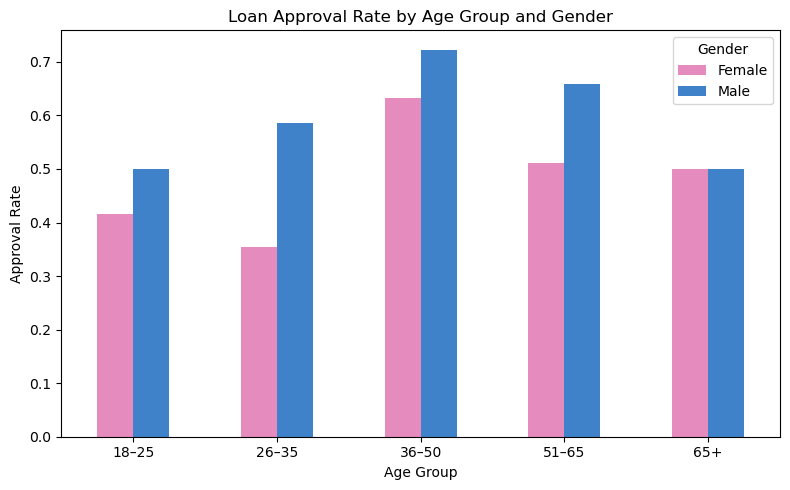

In [73]:
interaction_table = pd.crosstab(
    [df_bias["age_group"], df_bias["applicant_info.gender"]],
    df_bias["decision.loan_approved"],
    normalize="index"
)

interaction_approval = interaction_table[True].unstack()

interaction_approval.plot(
    kind="bar",
    figsize=(8,5),
    color=["#E68BBE", "#3F82C9"]
)

plt.title("Loan Approval Rate by Age Group and Gender")
plt.ylabel("Approval Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

The visualization shows that approval rates differ across both **age
groups and gender**. In most age categories, male applicants exhibit
higher approval rates than female applicants.

For example, the differences appear particularly noticeable in the
**26–35** and **51–65** age groups, where male approval rates exceed
female approval rates by a larger margin. In contrast, other groups,
such as **36–50**, display more similar approval outcomes across
genders.

These patterns suggest that disparities in approval outcomes may vary
across specific demographic subgroups rather than being explained by
gender or age alone.

To quantify these differences, we calculate the **Disparate Impact (DI)
ratio within each age group**, comparing female approval rates relative
to male approval rates.

As in the earlier gender analysis, DI values below **0.8** may indicate
potential disparate impact according to the **four-fifths rule**.

In [74]:
di_by_age = []

age_groups = df_bias["age_group"].unique()

for age in age_groups:
    
    subset = df_bias[df_bias["age_group"] == age]
    
    approval_rates = subset.groupby("applicant_info.gender")["decision.loan_approved"].mean()
    
    if "Male" in approval_rates and "Female" in approval_rates:
        di = approval_rates["Female"] / approval_rates["Male"]
    else:
        di = None
    
    di_by_age.append({
        "Age Group": age,
        "Male Approval Rate": approval_rates.get("Male", None),
        "Female Approval Rate": approval_rates.get("Female", None),
        "DI Ratio (F/M)": di
    })

# Create dataframe
di_age_df = pd.DataFrame(di_by_age)

# Add fairness threshold column (Four-Fifths Rule)
di_age_df["Below 0.8 Threshold"] = di_age_df["DI Ratio (F/M)"] < 0.8

# Optional: sort age groups for cleaner display
age_order = ["18–25", "26–35", "36–50", "51–65", "65+"]
di_age_df["Age Group"] = pd.Categorical(di_age_df["Age Group"], categories=age_order, ordered=True)
di_age_df = di_age_df.sort_values("Age Group")

di_age_df

,Age Group,Male Approval Rate,Female Approval Rate,DI Ratio (F/M),Below 0.8 Threshold
0,18–25,0.500000,0.416667,0.833333,False
1,26–35,0.586667,0.353659,0.602827,True
2,36–50,0.722689,0.632075,0.874616,False
3,51–65,0.657895,0.511111,0.776889,True
4,65+,0.500000,0.500000,1.000000,False


The calculated DI ratios reveal that most age groups have values above
the **0.8 threshold**, suggesting relatively balanced approval rates
between male and female applicants within those groups.

However, two age groups fall below the four-fifths rule threshold:
**26–35 (DI ≈ 0.60)** and **51–65 (DI ≈ 0.78)**. In these categories,
female applicants are approved at a substantially lower rate compared
to male applicants.

These results indicate that **gender disparities may be more pronounced
within certain age groups**, highlighting the importance of examining
interaction effects rather than analyzing demographic attributes in
isolation.

To formally evaluate whether approval outcomes depend on the combined
relationship between **age group and gender**, we perform a **Chi-Square
test of independence** using the interaction between these variables.

This test assesses whether loan approval outcomes vary systematically
across **age–gender subgroups** or whether the observed differences
could arise from random variation.

In [59]:
interaction_counts = pd.crosstab(
    [df_bias["age_group"], df_bias["applicant_info.gender"]],
    df_bias["decision.loan_approved"]
)

from scipy.stats import chi2_contingency

chi2_interaction, p_interaction, dof, expected = chi2_contingency(interaction_counts)

print("Chi-square statistic:", chi2_interaction)
print("p-value:", p_interaction)

Chi-square statistic: 32.02705987701472
p-value: 0.00019699520358552463


The Chi-Square test yields a statistic of **32.03** with a **p-value of
0.000197**.

Since the p-value is well below the conventional significance
threshold of **0.05**, we reject the null hypothesis that loan approval
is independent of the **combined effects of age and gender**.

This indicates that approval outcomes vary significantly across
different **age–gender subgroups** in the dataset. In other words,
approval patterns cannot be fully explained by age or gender alone,
but rather by the interaction between these attributes.

This result highlights the importance of considering **intersectional
effects** in fairness analysis, as disparities may emerge within
specific demographic subgroups even when overall patterns appear
relatively balanced.

## 6. Conclusion

This analysis evaluated potential bias in NovaCred’s credit approval
decisions by examining approval patterns across **gender, age, and
combined demographic groups**, as well as potential **proxy variables**
such as geographic and financial attributes.

TThe analysis reveals several interconnected patterns in the dataset.
Approval outcomes differ across both **gender and age groups**, with
female applicants receiving approvals at a lower rate than male
applicants and statistically significant differences also observed
across age categories.

Further investigation suggests that these disparities are not isolated
to individual attributes but are embedded within broader structural
patterns in the data. Geographic analysis showed that while **ZIP code
itself is not significantly associated with approval outcomes**, it is
strongly associated with **gender distribution**, indicating that
location may capture underlying demographic structure. At the same
time, financial variables such as **credit history length and income**
show moderate relationships with **age**, suggesting that some
financial characteristics may reflect life-cycle differences between
applicants.

Taken together, these results indicate that approval outcomes may be
shaped by a combination of **direct demographic differences, geographic
demographic clustering, and financial characteristics associated with
age**. The interaction analysis further highlights that disparities can
become more pronounced within specific **age–gender subgroups**,
demonstrating that demographic effects may emerge through
**intersectional patterns** rather than through single attributes
alone.

Beyond fairness considerations, the dataset also contains multiple
forms of **personally identifiable information (PII)**, including names,
emails, IP addresses, and social security numbers. The next section
therefore explores how sensitive personal data can be **pseudonymized
or anonymized** in order to reduce privacy risks while maintaining the
ability to conduct responsible governance analyses.